In [1]:
import trios_parser as tp

In [17]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_file = "/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/TRIOS/CruiseData/CruiseTest/CruiseTest20260401.dat"

In [10]:
devices_found = set()
with open(data_file, 'r') as f:
    for line in f:
        if "IDDevice" in line and "=" in line:
            # This splits by '=' and takes the second part,
            # then cleans up any spaces or hidden characters
            dev_id = line.split('=')[1].strip()
            devices_found.add(dev_id)

print(f"Devices found: {devices_found}")

Devices found: {'SAM_82CF', 'SAM_82C1', 'SAM_82CD'}


In [7]:
try:
    # 'CALIBRATED' is the standard for your coastal darkening thesis
    wl, spectra, timestamps = tp.ramses_parse(data_file,
                                              device='SAM_82C1', # Replace with your sensor SN
                                              datatype='CALIBRATED',
                                              timestamp=True)
    print(f"Successfully loaded {len(timestamps)} samples!")
except Exception as e:
    print(f"Check your file path or Device SN: {e}")

Successfully loaded 1158 samples!


In [13]:
# The three musketeers of your AOP setup
sensors = ['82C1', '82CD', '82CF']

# Example: Pulling the Water-viewing radiance
wl_Lw, spec_Lw, ts_Lw = tp.ramses_parse(data_file, device='SAM_82CF', datatype='CALIBRATED', timestamp=True)

# Example: Pulling the Sky-viewing radiance
wl_Lsky, spec_Lsky, ts_Lsky = tp.ramses_parse(data_file, device='SAM_82CD', datatype='CALIBRATED', timestamp=True)

# Example: Pulling the Downwelling irradiance
wl_Es, spec_Es, ts_Es = tp.ramses_parse(data_file, device='SAM_82C1', datatype='CALIBRATED', timestamp=True)

In [14]:
spec_Lw

array([[10.        , 10.        , 10.        , ..., 10.        ,
        10.        , 10.        ],
       [ 0.01942737,  0.01952077,  0.01935505, ...,  0.0277012 ,
         0.02697505,  0.02750836],
       [ 0.02680518,  0.02647893,  0.02641368, ...,  0.03524664,
         0.03491352,  0.03539775],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(256, 661))

<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\c'
C:\Users\25298423\AppData\Local\Temp\ipykernel_59416\683104074.py:9: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Calibrated Intensity ($mW \cdot m^{-2} \cdot nm^{-1}$)')


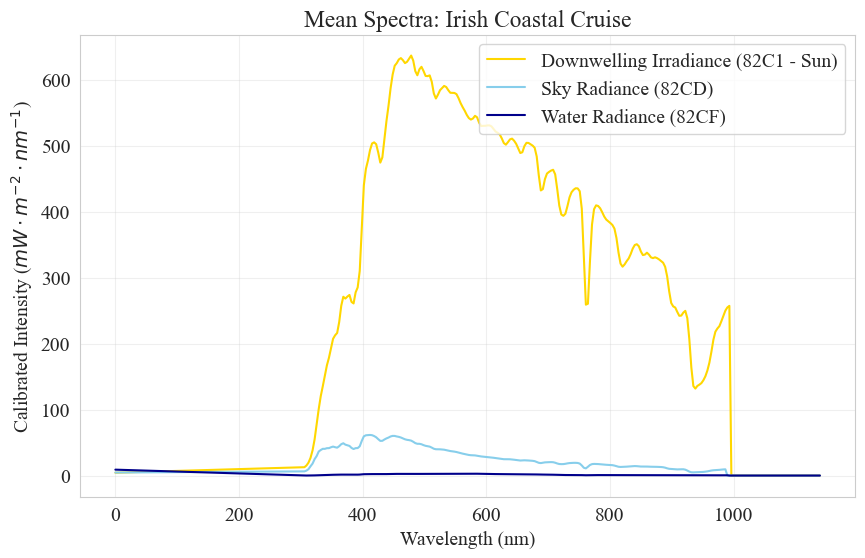

In [18]:
plt.figure(figsize=(10, 6))

# Plotting the mean spectrum for each sensor across all 5,956 samples
plt.plot(wl, np.mean(spec_Es, axis=1), label='Downwelling Irradiance (82C1 - Sun)', color='gold')
plt.plot(wl, np.mean(spec_Lsky, axis=1), label='Sky Radiance (82CD)', color='skyblue')
plt.plot(wl, np.mean(spec_Lw, axis=1), label='Water Radiance (82CF)', color='darkblue')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Calibrated Intensity ($mW \cdot m^{-2} \cdot nm^{-1}$)')
plt.title('Mean Spectra: Irish Coastal Cruise')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

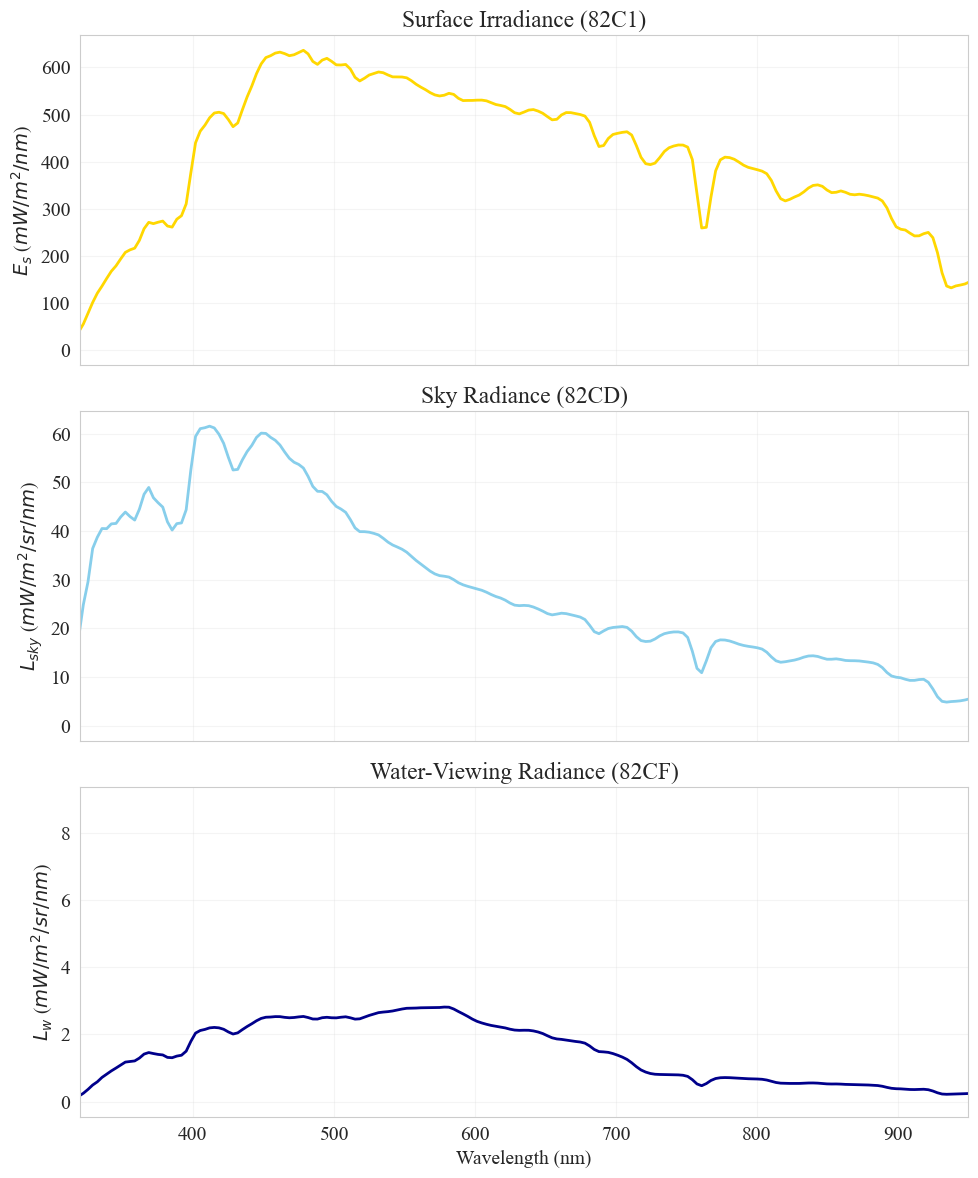

In [20]:
import matplotlib.pyplot as plt

# Create 3 stacked subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1. Downwelling Irradiance (The Sun)
ax1.plot(wl, spec_Es.mean(axis=1), color='gold', lw=2)
ax1.set_ylabel('$E_s$ ($mW/m^2/nm$)')
ax1.set_title('Surface Irradiance (82C1)')
ax1.grid(True, alpha=0.2)
plt.xlim(320, 950)

# 2. Sky Radiance
ax2.plot(wl, spec_Lsky.mean(axis=1), color='skyblue', lw=2)
ax2.set_ylabel('$L_{sky}$ ($mW/m^2/sr/nm$)')
ax2.set_title('Sky Radiance (82CD)')
ax2.grid(True, alpha=0.2)
plt.xlim(320, 950)

# 3. Water Radiance (The "Darkening" Signal)
ax3.plot(wl, spec_Lw.mean(axis=1), color='darkblue', lw=2)
ax3.set_ylabel('$L_w$ ($mW/m^2/sr/nm$)')
ax3.set_title('Water-Viewing Radiance (82CF)')
ax3.set_xlabel('Wavelength (nm)')
ax3.grid(True, alpha=0.2)
plt.xlim(320, 950)

plt.tight_layout()
plt.show()